# House Price Prediction using Machine Learning

This notebook performs exploratory data analysis (EDA) on a house price dataset, 
followed by data visualization and training multiple regression models 
(Linear Regression, Ridge, Lasso, Random Forest, etc.) to predict house prices 
based on features like area, bedrooms, location score, and more.

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/engraamirjamil/house-price-prediction/House_Price_Prediction_1500_Records.csv


In [2]:
# EDA
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

# Machine Learning 
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
# models 
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor


# setup plots 
sns.set_style('darkgrid')
plt.rcParams['figure.figsize'] = (10, 4)

# filter warning
import warnings as w
w.filterwarnings('ignore')

# pickle (save model and parameters)
import pickle

# time stamp
import time
print(f"Last Update : {time.asctime()}")

Last Update : Thu Aug  6 06:43:04 2026


## Load data

In [3]:
df = pd.read_csv('/kaggle/input/datasets/engraamirjamil/house-price-prediction/House_Price_Prediction_1500_Records.csv')
df.head(1)

,Area_sqft,Bedrooms,Bathrooms,Floors,Age,Garage,LocationScore,DistanceToCity_km,Condition,Price
0,2728.0,1.0,4.0,2.0,7.0,0.0,3.0,NaN,Fair,547397


## EDA 

### Basic info

In [4]:
# shape
df.shape

(1500, 10)

In [5]:
# info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Area_sqft          1374 non-null   float64
 1   Bedrooms           1376 non-null   float64
 2   Bathrooms          1375 non-null   float64
 3   Floors             1379 non-null   float64
 4   Age                1394 non-null   float64
 5   Garage             1363 non-null   float64
 6   LocationScore      1385 non-null   float64
 7   DistanceToCity_km  1376 non-null   float64
 8   Condition          1371 non-null   object 
 9   Price              1500 non-null   int64  
dtypes: float64(8), int64(1), object(1)
memory usage: 117.3+ KB


In [6]:
df.describe()

,Area_sqft,Bedrooms,Bathrooms,Floors,Age,Garage,LocationScore,DistanceToCity_km,Price
count,1374.000000,1376.000000,1375.000000,1379.000000,1394.000000,1363.000000,1385.000000,1376.000000,1.500000e+03
mean,2719.296943,3.516715,3.013091,2.008702,24.982783,1.471753,5.483032,20.632703,5.627358e+05
std,1262.733349,1.688381,1.426961,0.809906,14.791676,1.105872,2.906025,11.447891,2.301102e+05
min,607.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.046870e+05
25%,1633.500000,2.000000,2.000000,1.000000,12.000000,0.000000,3.000000,10.400000,3.668225e+05
50%,2681.000000,4.000000,3.000000,2.000000,25.000000,1.000000,6.000000,20.250000,5.560690e+05
75%,3832.750000,5.000000,4.000000,3.000000,37.750000,2.000000,8.000000,30.600000,7.488978e+05
max,5000.000000,6.000000,5.000000,3.000000,50.000000,3.000000,10.000000,40.000000,1.054839e+06


In [7]:
df.isnull().sum()

Area_sqft            126
Bedrooms             124
Bathrooms            125
Floors               121
Age                  106
Garage               137
LocationScore        115
DistanceToCity_km    124
Condition            129
Price                  0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.columns

Index(['Area_sqft', 'Bedrooms', 'Bathrooms', 'Floors', 'Age', 'Garage',
       'LocationScore', 'DistanceToCity_km', 'Condition', 'Price'],
      dtype='object')

In [10]:
# Check unique categories in 'Condition' column
df['Condition'].unique()

array(['Fair', 'Excellent', 'Poor', nan, 'Good'], dtype=object)

In [11]:
# Count how many houses fall into each condition category
df['Condition'].value_counts()

Condition
Fair         347
Good         345
Excellent    341
Poor         338
Name: count, dtype: int64

In [12]:
# Check skewness of target variable (Price)
# Skewness close to 0 = normal distribution, positive = right-skewed, negative = left-skewed
df['Price'].skew()

np.float64(0.0780464282778948)

In [13]:
# Separate numeric and categorical columns for missing value treatment
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns.drop('Price')
categorical_cols = ['Condition']

# Fill missing numeric values with median (robust to outliers, unlike mean)
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# Fill missing categorical values with mode (most frequent category)
df['Condition'] = df['Condition'].fillna(df['Condition'].mode()[0])

# Verify no missing values remain
df.isnull().sum()

Area_sqft            0
Bedrooms             0
Bathrooms            0
Floors               0
Age                  0
Garage               0
LocationScore        0
DistanceToCity_km    0
Condition            0
Price                0
dtype: int64

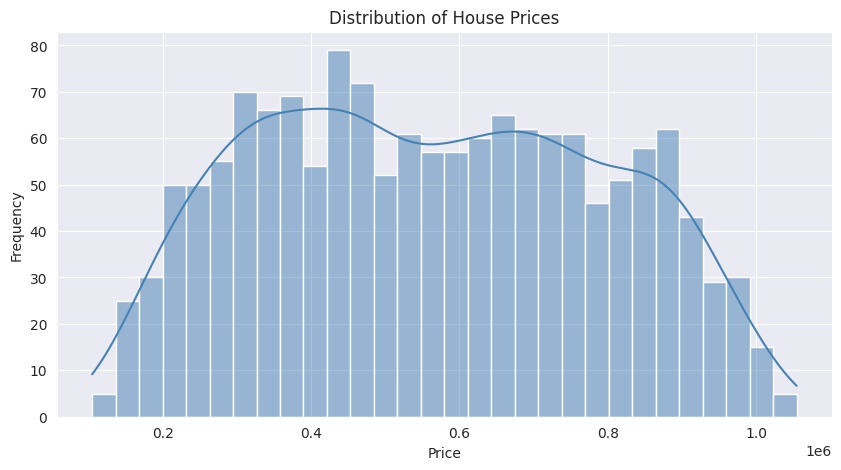

In [14]:
# Visualize distribution of target variable 'Price'
plt.figure(figsize=(10, 5))
sns.histplot(df['Price'], kde=True, bins=30, color='steelblue')
plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

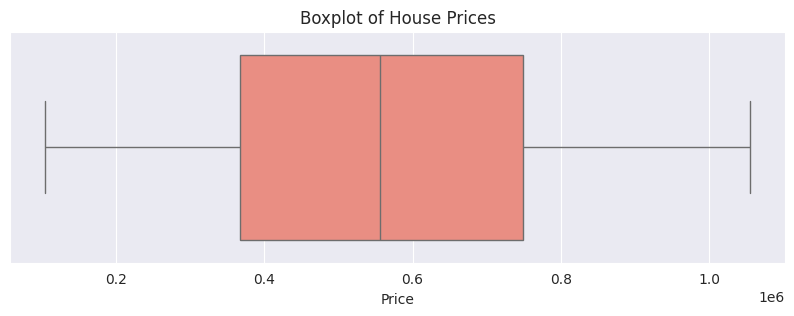

In [15]:
# Boxplot to check outliers in Price
plt.figure(figsize=(10, 3))
sns.boxplot(x=df['Price'], color='salmon')
plt.title('Boxplot of House Prices')
plt.show()

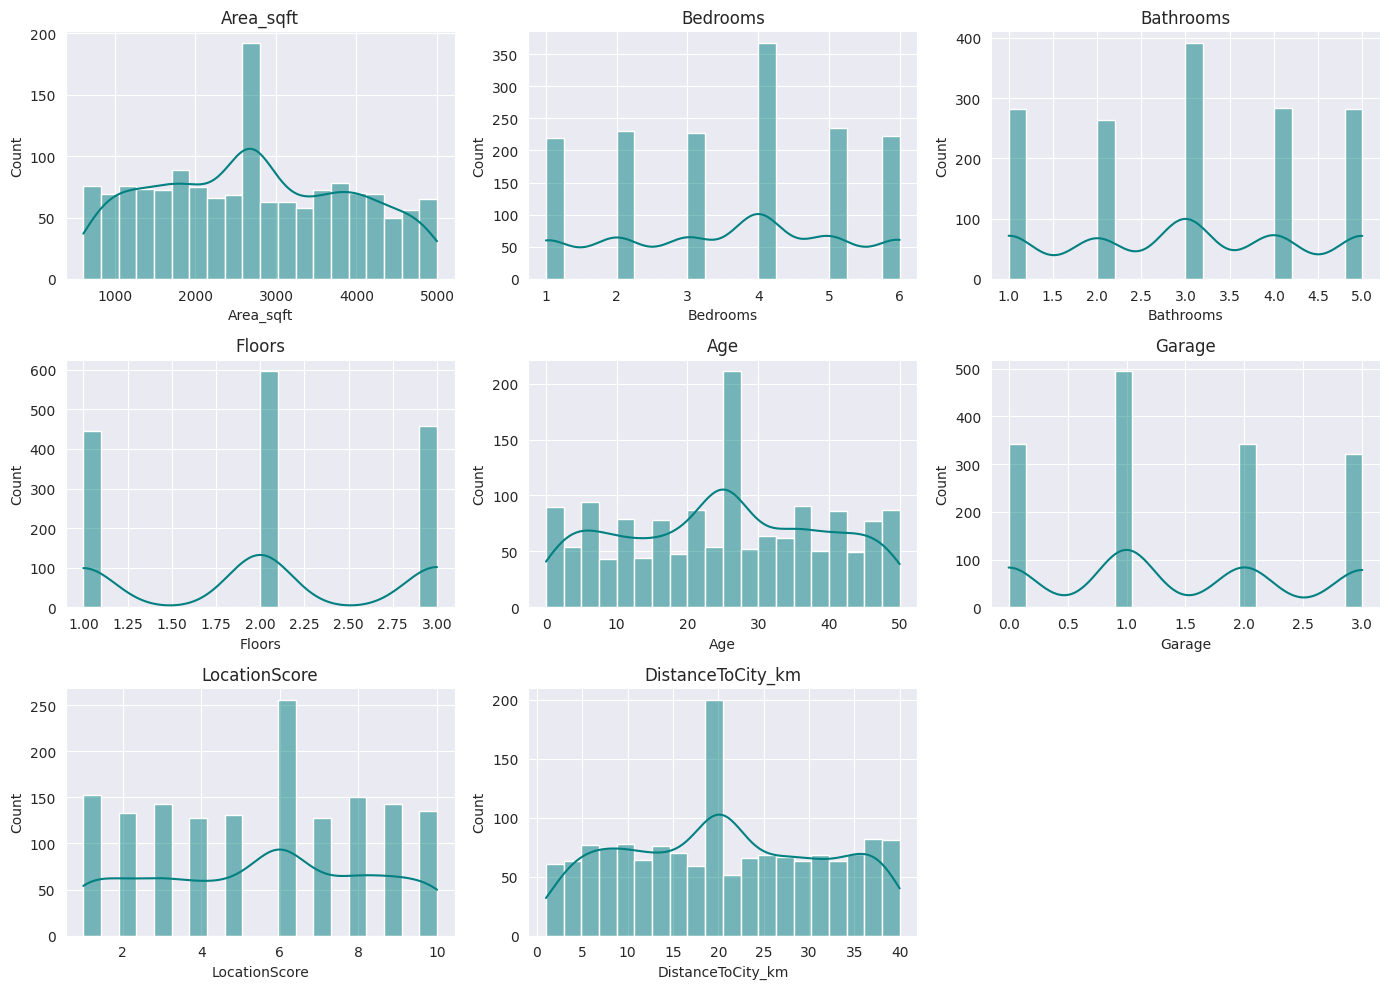

In [16]:
# Distribution of all numeric features
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns.drop('Price')

plt.figure(figsize=(14, 10))
for i, col in enumerate(numeric_cols):
    plt.subplot(3, 3, i + 1)
    sns.histplot(df[col], kde=True, bins=20, color='teal')
    plt.title(col)
plt.tight_layout()
plt.show()

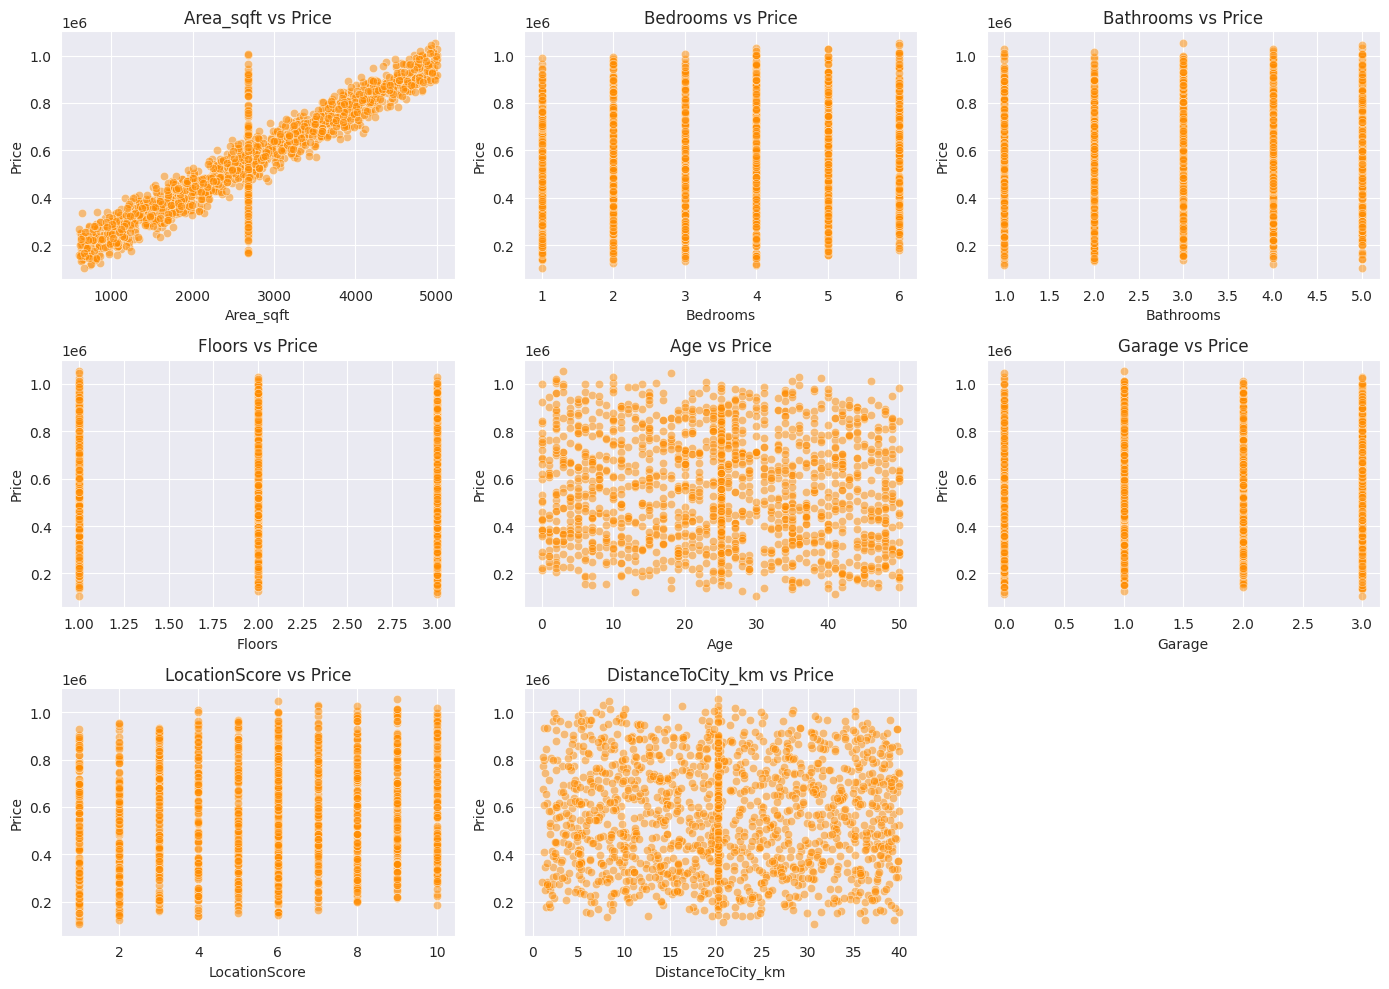

In [17]:
# Scatter plots to see relationship between each feature and Price
plt.figure(figsize=(14, 10))
for i, col in enumerate(numeric_cols):
    plt.subplot(3, 3, i + 1)
    sns.scatterplot(x=df[col], y=df['Price'], color='darkorange', alpha=0.5)
    plt.title(f'{col} vs Price')
plt.tight_layout()
plt.show()

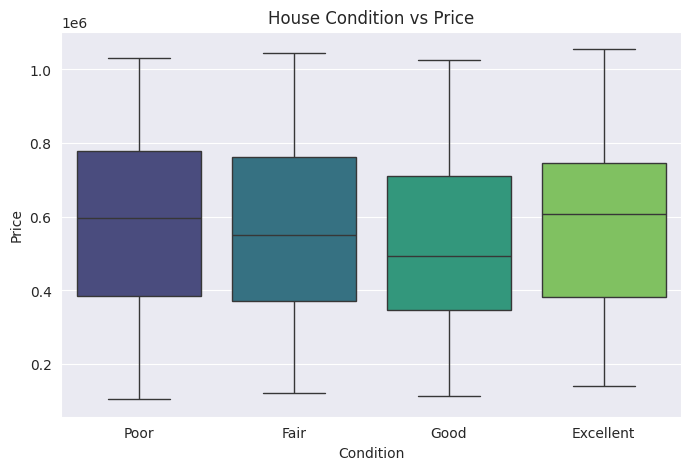

In [18]:
# Boxplot to see how house condition affects price
plt.figure(figsize=(8, 5))
sns.boxplot(x='Condition', y='Price', data=df, order=['Poor', 'Fair', 'Good', 'Excellent'], palette='viridis')
plt.title('House Condition vs Price')
plt.xlabel('Condition')
plt.ylabel('Price')
plt.show()

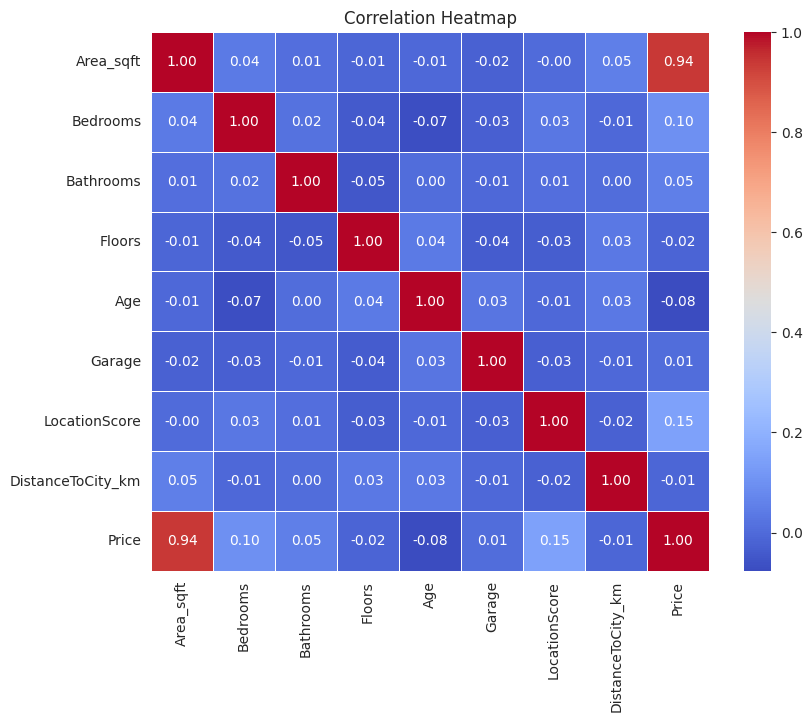

In [19]:
# Correlation heatmap to see how strongly numeric features relate to each other and to Price
plt.figure(figsize=(9, 7))
correlation_matrix = df.corr(numeric_only=True)
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

In [20]:
# Function to detect outliers using IQR method
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

# Check outliers in Price
price_outliers, low, up = detect_outliers_iqr(df, 'Price')
print(f"Number of outliers in Price: {len(price_outliers)}")
print(f"Lower bound: {low:.2f}, Upper bound: {up:.2f}")

Number of outliers in Price: 0
Lower bound: -206290.38, Upper bound: 1322010.62


In [21]:
# Check outliers in Area_sqft
area_outliers, low, up = detect_outliers_iqr(df, 'Area_sqft')
print(f"Number of outliers in Area_sqft: {len(area_outliers)}")
print(f"Lower bound: {low:.2f}, Upper bound: {up:.2f}")

Number of outliers in Area_sqft: 0
Lower bound: -1246.38, Upper bound: 6708.62


In [22]:
# Label Encoding for 'Condition' column (converts categories into numeric labels)
le = LabelEncoder()
df_encoded = df.copy()
df_encoded['Condition'] = le.fit_transform(df_encoded['Condition'])

# Check encoded values
df_encoded[['Condition']].head()

,Condition
0,1
1,0
2,0
3,1
4,1


## Pre-processing

In [23]:
# Separate features and target variable
X = df_encoded.drop('Price', axis=1)
y = df_encoded['Price']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (1500, 9)
Target shape: (1500,)


In [24]:
# Split data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set: {X_train.shape}")
print(f"Testing set: {X_test.shape}")

Training set: (1200, 9)
Testing set: (300, 9)


In [25]:
# Scale features (important for models like SVR, KNN, Linear Regression with regularization)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Model Building

In [26]:
# train all 

In [27]:
models = {
       'Linear Regression':LinearRegression(),
       'Ridge': Ridge(),
       'Lasso': Lasso(),
       'ElasticNet':ElasticNet(),
       'DecisionTreeRegressor':DecisionTreeRegressor(),
       'RandomForestRegressor':RandomForestRegressor(),
       'GradientBoostingRegressor':GradientBoostingRegressor(),
       'AdaBoostRegressor':AdaBoostRegressor(),
       'SVR':SVR(),
       'KNeighborsRegressor':KNeighborsRegressor()
}


In [28]:
results = []
fitted_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')

    results.append({
        'Model': name, 'RMSE': rmse, 'MAE': mae,
        'R2': r2, 'CV_R2_mean': cv_scores.mean()
    })
    fitted_models[name] = model

    print(f"{name:20s} | RMSE: {rmse:,.2f} | MAE: {mae:,.2f} | R2: {r2:.4f} | CV R2: {cv_scores.mean():.4f}")

Linear Regression    | RMSE: 72,968.53 | MAE: 35,090.06 | R2: 0.8992 | CV R2: 0.9201
Ridge                | RMSE: 72,968.73 | MAE: 35,090.31 | R2: 0.8992 | CV R2: 0.9201
Lasso                | RMSE: 72,968.65 | MAE: 35,090.06 | R2: 0.8992 | CV R2: 0.9201
ElasticNet           | RMSE: 73,171.85 | MAE: 35,368.88 | R2: 0.8986 | CV R2: 0.9200
DecisionTreeRegressor | RMSE: 125,085.56 | MAE: 66,325.51 | R2: 0.7037 | CV R2: 0.7917
RandomForestRegressor | RMSE: 76,279.25 | MAE: 41,849.32 | R2: 0.8898 | CV R2: 0.9033
GradientBoostingRegressor | RMSE: 75,376.34 | MAE: 40,310.15 | R2: 0.8924 | CV R2: 0.9104
AdaBoostRegressor    | RMSE: 84,805.83 | MAE: 57,278.69 | R2: 0.8638 | CV R2: 0.8691
SVR                  | RMSE: 230,432.37 | MAE: 199,880.06 | R2: -0.0055 | CV R2: -0.0009
KNeighborsRegressor  | RMSE: 93,099.38 | MAE: 58,016.27 | R2: 0.8359 | CV R2: 0.8777


In [29]:
results_df=pd.DataFrame(results).sort_values('R2',ascending=False).reset_index(drop=True)
results_df

,Model,RMSE,MAE,R2,CV_R2_mean
0,Linear Regression,72968.525225,35090.056829,0.899173,0.920124
1,Lasso,72968.646683,35090.064771,0.899173,0.920124
2,Ridge,72968.730557,35090.313022,0.899173,0.920124
3,ElasticNet,73171.848932,35368.875809,0.898611,0.919998
4,GradientBoostingRegressor,75376.343009,40310.146273,0.892409,0.910427
5,RandomForestRegressor,76279.251483,41849.316733,0.889816,0.903260
6,AdaBoostRegressor,84805.834847,57278.694136,0.863807,0.869127
7,KNeighborsRegressor,93099.377940,58016.273333,0.835866,0.877741
8,DecisionTreeRegressor,125085.559754,66325.513333,0.703709,0.791660
9,SVR,230432.371290,199880.055930,-0.005521,-0.000905


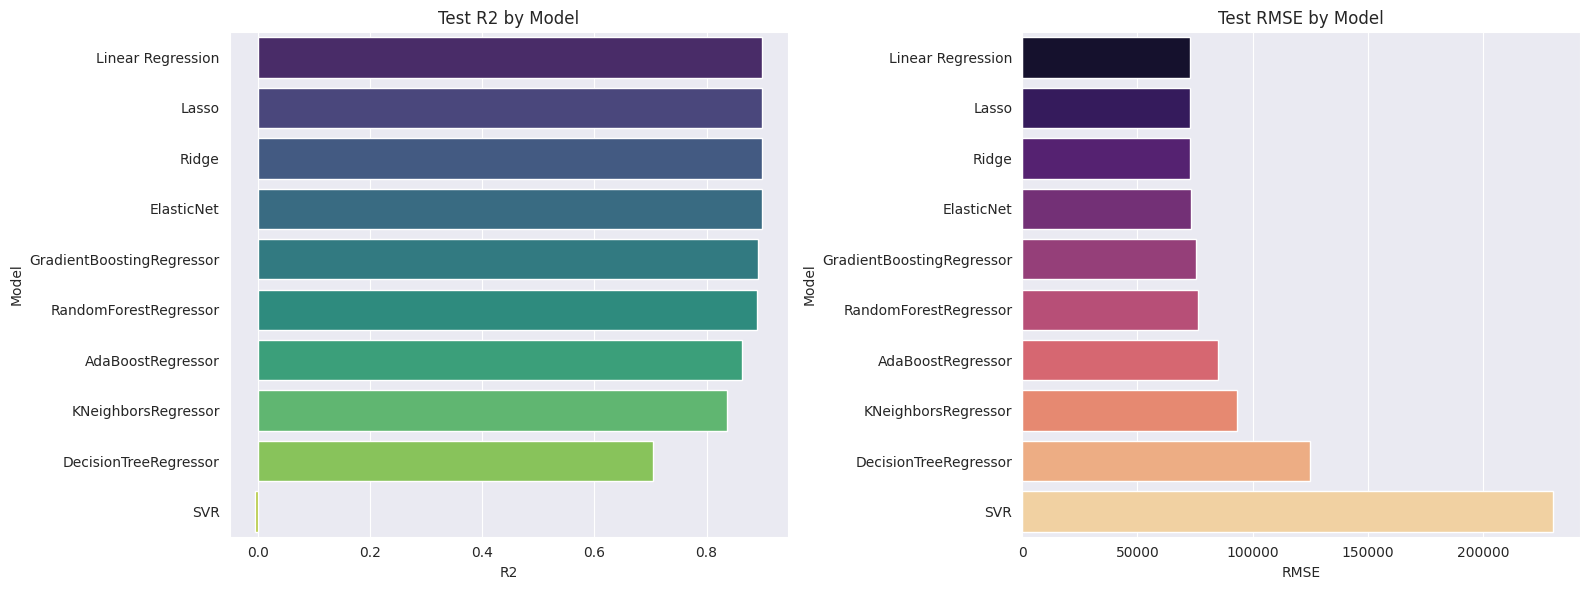

Best baseline model: Linear Regression


In [30]:
fig,axes = plt.subplots(1,2,figsize=(16,6))
sns.barplot(x='R2' ,y='Model' , data=results_df ,ax=axes[0],palette='viridis')
axes[0].set_title('Test R2 by Model')
sns.barplot(x='RMSE', y='Model', data= results_df, ax=axes[1],palette='magma')
axes[1].set_title('Test RMSE by Model')
plt.tight_layout()
plt.show()
best_model_name = results_df.iloc[0]['Model']
print("Best baseline model:",best_model_name)

In [31]:
# hypertune gradient boosting regressor

param_grid = {
    'n_estimators':[100,200,300],
    'learning_rate':[0.01,0.05,0.1],
    'max_depth':[2,3,4],
    'subsample':[0.8,1.0]
}

In [32]:
grid = GridSearchCV(
    estimator=GradientBoostingRegressor(),
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    verbose=1
)

In [33]:
# Fit GridSearchCV on training data (this will take some time depending on param_grid size)
grid.fit(X_train_scaled, y_train)

Fitting 5 folds for each of 54 candidates, totalling 270 fits


GridSearchCV(cv=5, estimator=GradientBoostingRegressor(),
             param_grid={'learning_rate': [0.01, 0.05, 0.1],
                         'max_depth': [2, 3, 4],
                         'n_estimators': [100, 200, 300],
                         'subsample': [0.8, 1.0]},
             scoring='r2', verbose=1)

In [34]:
# Best hyperparameters found
print("Best Parameters:", grid.best_params_)

Best Parameters: {'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 300, 'subsample': 0.8}


In [35]:
# Best cross-validation R2 score
print("Best CV R2 Score:", grid.best_score_)

Best CV R2 Score: 0.9130255887922324


In [36]:
# Get best model
best_model = grid.best_estimator_

# Predict on test set
y_pred_best = best_model.predict(X_test_scaled)

# Calculate final evaluation metrics
final_rmse = np.sqrt(mean_squared_error(y_test, y_pred_best))
final_mae = mean_absolute_error(y_test, y_pred_best)
final_r2 = r2_score(y_test, y_pred_best)

print(f"Final RMSE: {final_rmse:.2f}")
print(f"Final MAE: {final_mae:.2f}")
print(f"Final R2 Score: {final_r2:.4f}")

Final RMSE: 74701.34
Final MAE: 39862.80
Final R2 Score: 0.8943


In [37]:
# Save the trained model, scaler, and label encoder using pickle
# This allows us to reuse them later without retraining

import pickle

# Save the best trained model
with open('best_model.pkl', 'wb') as file:
    pickle.dump(best_model, file)

# Save the StandardScaler (used for feature scaling)
with open('scaler.pkl', 'wb') as file:
    pickle.dump(scaler, file)

# Save the LabelEncoder (used for encoding 'Condition' column)
with open('label_encoder.pkl', 'wb') as file:
    pickle.dump(le, file)

print("Model, scaler, and encoder saved successfully!")

Model, scaler, and encoder saved successfully!


In [38]:
# Load saved model, scaler, and encoder (for future predictions)
with open('best_model.pkl', 'rb') as file:
    loaded_model = pickle.load(file)

with open('scaler.pkl', 'rb') as file:
    loaded_scaler = pickle.load(file)

with open('label_encoder.pkl', 'rb') as file:
    loaded_encoder = pickle.load(file)

print("Model, scaler, and encoder loaded successfully!") 

Model, scaler, and encoder loaded successfully!
